# 1. Khai báo thư viện và đọc dữ liệu

In [1]:
mooccubex_cleaned_path = '/kaggle/input/mooccubex-cleaned'
data_label_path  ='/kaggle/input/d-liu-gn-nhn'
import matplotlib.pyplot as plt
import pandas as pd
import json
import gzip
import bz2
import orjson

def read_jsonl_in_batches(file_path, batch_size=10000, use_orjson=True):
    """
    Đọc file JSON Lines theo từng batch và yield DataFrame.

    Parameters
    ----------
    file_path : str
        Đường dẫn tới file JSONL (có thể nén .gz hoặc .bz2)
    batch_size : int
        Số dòng mỗi batch
    use_orjson : bool
        Sử dụng orjson để tăng tốc (nếu có cài đặt)

    Yields
    ------
    pd.DataFrame
        Batch dữ liệu dưới dạng DataFrame
    """

    # Chọn thư viện parse JSON
    json_loader = orjson.loads if use_orjson else json.loads

    # Chọn method mở file (hỗ trợ file nén)
    if file_path.endswith(".gz"):
        open_func = gzip.open
    elif file_path.endswith(".bz2"):
        open_func = bz2.open
    else:
        open_func = open

    total_lines = 0
    error_lines = 0
    batch = []

    try:
        with open_func(file_path, 'rt', encoding='utf-8') as file:
            for line_num, line in enumerate(file, start=1):
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json_loader(line)
                    batch.append(obj)
                except Exception as e:
                    error_lines += 1
                    print(f"[Warning] Lỗi parse JSON tại dòng {line_num}: {e}")
                    continue

                if len(batch) >= batch_size:
                    yield pd.DataFrame(batch)
                    total_lines += len(batch)
                    batch = []

            # Batch cuối
            if batch:
                yield pd.DataFrame(batch)
                total_lines += len(batch)

    except FileNotFoundError:
        print(f"[Error] File không tồn tại: {file_path}")
    except Exception as e:
        print(f"[Error] Lỗi khi đọc file: {e}")

    print(f"[Done] Đọc xong {total_lines} dòng hợp lệ, {error_lines} dòng lỗi.")

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("kaggle-pyspark")
    .master("local[*]")                    # chạy local trên CPU của phiên Kaggle
    .config("spark.driver.memory", "8g")   # có thể giảm/tăng tùy RAM phiên làm việc
    .config("spark.sql.shuffle.partitions", "200")  # chỉnh cho phù hợp dữ liệu
    .getOrCreate()
)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 02:37:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Doc du lieu problem va user-problem
problem_df = pd.read_parquet(mooccubex_cleaned_path + '/problem_df_cleaned.parquet')
user_problem_df = spark.read.parquet('/kaggle/input/d-liu-gn-nhn/user-problem-split-20251006T061232Z-1-001/user-problem-split')
problem_df

,problem_id,title,content,option,answer,score,typetext,location,context_id,exercise_id,language_Chinese,language_English,type_1,type_2,type_3,type_4,type_5,type_6,course_id
0,Pm_1730,第一课 导论与三家分晋--习题,1、《资治通鉴》卷1记载：智宣子将以瑶为后，智果曰：“……瑶之贤于人者五，其不逮者一也。美鬓...,"{'A': '武艺超群，精通射御之术', 'B': '礼贤下士，虚怀若谷', 'C': '反...","[""B""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
1,Pm_1731,第一课 导论与三家分晋--习题,2、《资治通鉴》是一部____史书。,"{'A': '纪传体', 'B': '编年体', 'C': '纪事本末体', 'D': '国...","[""B""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
2,Pm_1732,第一课 导论与三家分晋--习题,3、《资治通鉴》原名____，后由____赐名“资治通鉴”。,"{'A': '《通鉴》；宋神宗', 'B': '《通志》；宋徽宗', 'C': '《通鉴》；...","[""D""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
3,Pm_1733,第一课 导论与三家分晋--习题,4、“三家分晋”中“三家”具体指：,"{'A': '魏赵韩', 'B': '魏韩智', 'C': '赵韩智', 'D': '魏赵智'}","[""A""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
4,Pm_1734,第一课 导论与三家分晋--习题,5、智伯联合韩、魏的军队攻打赵氏时，赵襄子选择退守的阵地是：,"{'A': '邯郸', 'B': '长子', 'C': '晋阳', 'D': '皋狼'}","[""C""]",1.0,单选题,1.4,"[8045581, 8045582, 8045583]",Ex_856,1,0,1,0,0,0,0,0,C_584313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89208,Pm_2416818,习题10.1（共6题、满分20分）,有一个4位的D/A转换器，设它的FSR为7.5V，当输入数字量为1101时，输出电压为,"{'A': '4 V', 'B': '6.5 V', 'C': '8.25 V', 'D':...","[""B""]",2.0,单选题,10.6,[6339736],Ex_2144960,1,0,1,0,0,0,0,0,C_1410106
89209,Pm_2416819,习题10.1（共6题、满分20分）,倒T形电阻网络DAC相比权电阻网络DAC具有的优点不包含,"{'A': '电阻值范围小', 'B': '便于集成', 'C': '无寄生电容充放电现象'...","[""D""]",2.0,单选题,10.6,[6339736],Ex_2144960,1,0,1,0,0,0,0,0,C_1410106
89210,Pm_2416826,第一章作业题,组织与人力资源管理的四大匹配是刚刚匹配，人人匹配，人岗匹配和人的需求与岗位供给匹配,"{'true': '正确', 'false': '错误'}","[""true""]",1.0,判断题,5,"[6337887, 6337895, 6337904, 6337910, 6337917]",Ex_2144988,1,0,0,0,0,0,0,1,C_1410117
89211,Pm_2416827,第一章作业题,人力资源就是人力资本，两者没有任何区别。,"{'true': '正确', 'false': '错误'}","[""false""]",1.0,判断题,5,"[6337887, 6337895, 6337904, 6337910, 6337917]",Ex_2144988,1,0,0,0,0,0,0,1,C_1410117


In [4]:
user_problem_df.show(5)

+--------+----------+----------------+----------+-----+-------------------+----------+
|attempts|is_correct|          log_id|problem_id|score|        submit_time|   user_id|
+--------+----------+----------------+----------+-----+-------------------+----------+
|       1|         0|10194888_1847663|Pm_1847663|  0.0|2020-07-31 21:29:01|U_10194888|
|       1|         0|10073375_5958338|Pm_5958338| NULL|2020-10-21 22:31:14|U_10073375|
|       1|         1|10460549_3296034|Pm_3296034|  2.0|2020-06-21 18:22:46|U_10460549|
|       1|         1|10458826_1470153|Pm_1470153|  1.0|2020-06-03 10:38:28|U_10458826|
|       1|         1|10187156_1607843|Pm_1607843|  1.0|2020-05-21 21:13:54|U_10187156|
+--------+----------+----------------+----------+-----+-------------------+----------+
only showing top 5 rows



# 2. Xử lý dữ liệu file user-problem

## 2.1 Giao user-problem với problem_cleaned

- Nhầm giữ lại những problem có thông tin trong problem đã được làm sạch

In [5]:
from pyspark.sql.functions import broadcast

# 1. Chọn các cột cần thiết từ pandas DataFrame
problem_selected_df = problem_df[['problem_id', 'type_1','type_2',	'type_3','type_4','type_5',
                                  'type_6', 'score', 'exercise_id', 'course_id']]

# 2. Đổi tên cột score của problem thành max_score_for_problem
problem_selected_df = problem_selected_df.rename(columns={'score': 'max_score_for_problem'})

# 3. Chuyển pandas DataFrame sang Spark DataFrame
problem_spark_df = spark.createDataFrame(problem_selected_df)

# 4. Join với user_problem_df, chỉ giữ những problem_id hợp lệ
user_problem_filtered_df = user_problem_df.join(
    broadcast(problem_spark_df),
    on='problem_id',
    how='inner'
)

# 5. Xem kết quả
user_problem_filtered_df.show(5)
user_problem_filtered_df.printSchema()


25/10/26 02:37:54 WARN TaskSetManager: Stage 2 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+----------+--------+----------+----------------+-----+-------------------+----------+------+------+------+------+------+------+---------------------+-----------+---------+
|problem_id|attempts|is_correct|          log_id|score|        submit_time|   user_id|type_1|type_2|type_3|type_4|type_5|type_6|max_score_for_problem|exercise_id|course_id|
+----------+--------+----------+----------------+-----+-------------------+----------+------+------+------+------+------+------+---------------------+-----------+---------+
| Pm_626065|       1|         0| 10408789_626065|  0.0|2020-08-11 22:19:44|U_10408789|     0|     1|     0|     0|     0|     0|                  2.0|  Ex_499793| C_697031|
| Pm_713971|       1|         1| 10099604_713971|  5.0|2020-06-04 15:50:07|U_10099604|     1|     0|     0|     0|     0|     0|                  1.0|  Ex_572895| C_707365|
| Pm_641696|       1|         1| 10259371_641696|  2.0|2020-06-24 14:49:19|U_10259371|     0|     1|     0|     0|     0|     0|       

- Đếm số lượng dòng null của mỗi cột

In [6]:
from pyspark.sql import functions as F

null_counts = user_problem_filtered_df .select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in user_problem_df.columns
])

null_counts.show()

25/10/26 02:37:58 WARN TaskSetManager: Stage 4 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+--------+----------+------+----------+------+-----------+-------+
|attempts|is_correct|log_id|problem_id| score|submit_time|user_id|
+--------+----------+------+----------+------+-----------+-------+
|       0|         0|     0|         0|236775|          0|      0|
+--------+----------+------+----------+------+-----------+-------+



- Xác định số lượng score bị null theo 2 trường hợp is_correct bằng 1 và 0

In [7]:
score_null_df = user_problem_filtered_df .filter(F.col('score').isNull())
count_df = score_null_df.groupBy('is_correct').count()
count_df.show()

25/10/26 02:38:34 WARN TaskSetManager: Stage 8 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+----------+------+
|is_correct| count|
+----------+------+
|         0| 31006|
|         1|205769|
+----------+------+



**- Trực quan hóa tỉ lệ null**

25/10/26 02:38:48 WARN TaskSetManager: Stage 12 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


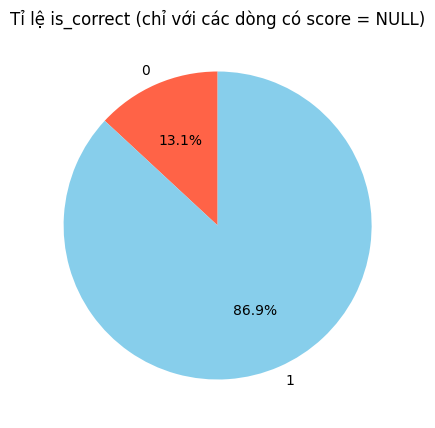

In [8]:
count_pd = count_df.toPandas()
count_pd['percent'] = count_pd['count'] / count_pd['count'].sum() * 100


plt.figure(figsize=(5,5))
plt.pie(count_pd['percent'], labels=count_pd['is_correct'],
        autopct='%1.1f%%', startangle=90, colors=['tomato','skyblue'])
plt.title('Tỉ lệ is_correct (chỉ với các dòng có score = NULL)')
plt.show()

## 2.2 Điền thiếu dữ liệu cột score user-problem

- Điều kiện điền thiếu :
  + Nếu is_correct = 1 thì điền max_score của problem cho bài làm
  + Nếu is_correct = 0 thì điền 0 cho bài làm của người dùng

In [9]:
from pyspark.sql.functions import col, when

# Giả sử user_problem_filtered_df có các cột:
# attempts, is_correct, log_id, problem_id, score, submit_time, user_id, max_score_for_problem

# Điền missing value cho cột score theo điều kiện
user_problem_filtered_df = user_problem_filtered_df.withColumn(
    'score',
    when(col('score').isNull() & (col('is_correct') == 0), 0)
    .when(col('score').isNull() & (col('is_correct') == 1), col('max_score_for_problem'))
    .otherwise(col('score'))  # giữ nguyên nếu không null
)

In [10]:
from pyspark.sql import functions as F

null_counts = user_problem_filtered_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in user_problem_df.columns
])

null_counts.show()

25/10/26 02:39:01 WARN TaskSetManager: Stage 16 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+--------+----------+------+----------+-----+-----------+-------+
|attempts|is_correct|log_id|problem_id|score|submit_time|user_id|
+--------+----------+------+----------+-----+-----------+-------+
|       0|         0|     0|         0|    0|          0|      0|
+--------+----------+------+----------+-----+-----------+-------+



## 2.3 Xử lý lỗi lưu trữ điểm trong user-problem

- Kiểm tra số lượng is_correct = 0 nhưng vẫn có điểm bài tập

In [11]:
check_not_correct_have_score = user_problem_filtered_df.select(
    F.count(
        F.when(
            (F.col('is_correct') == 0) & (F.col('score') != 0), 1
        )
    ).alias('count_not_correct_have_score')
)

check_not_correct_have_score.show()

25/10/26 02:39:30 WARN TaskSetManager: Stage 20 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+----------------------------+
|count_not_correct_have_score|
+----------------------------+
|                        5223|
+----------------------------+



Dựa vào phân tích bên dưới ta có thể nhận thấy các cột dòng dữ liệu có is_correct = 0 nhưng vẫn có điểm là do thuộc các nhóm câu hỏi Câu hỏi trắc nghiệm nhiều đáp án(type 2),Câu hỏi điền vào chỗ trống(type 4), Câu hỏi chủ quan(type 5)


In [12]:
from pyspark.sql.functions import col, sum as spark_sum

type_columns = ['type_1', 'type_2', 'type_3', 'type_4', 'type_5', 'type_6']

# Tạo DataFrame tổng hợp số lượng theo type
count_per_type_df = user_problem_filtered_df.filter(
    (col('is_correct') == 0) & (col('score') != 0)
).select([
    spark_sum(col(t)).alias(t) for t in type_columns
])

count_per_type_df.show()

25/10/26 02:39:46 WARN TaskSetManager: Stage 24 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+------+------+------+------+------+------+
|type_1|type_2|type_3|type_4|type_5|type_6|
+------+------+------+------+------+------+
|     0|  1491|     0|   894|  2838|     0|
+------+------+------+------+------+------+



- Xác định các lỗi dữ liệu:
   + Lỗi điểm âm
   + Lỗi điểm lớn hơn max_score
   + Lỗi is_correct = 1 nhưng điểm <=0

In [13]:
from pyspark.sql.functions import col

# Lọc score < 0
negative_score_df = user_problem_filtered_df.filter(col('score') < 0)

# Lọc score > max_score_for_problem
over_max_score_df = user_problem_filtered_df.filter(col('score') > col('max_score_for_problem'))

# Hoặc gộp lại 1 lần
abnormal_score_df = user_problem_filtered_df.filter(
    (col('score') < 0) | (col('score') > col('max_score_for_problem'))
)
negative_score_df.count()  # số dòng score < 0
over_max_score_df.count()  # số dòng score > max_score_for_problem
abnormal_score_df.count()  # tổng số dòng bất thường

25/10/26 02:39:54 WARN TaskSetManager: Stage 28 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.
25/10/26 02:40:10 WARN TaskSetManager: Stage 32 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.
25/10/26 02:40:27 WARN TaskSetManager: Stage 36 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


3113

In [14]:
abnormal_score_df.select('user_id','problem_id','score','max_score_for_problem','is_correct').show(20)

25/10/26 02:40:44 WARN TaskSetManager: Stage 40 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+----------+----------+-----+---------------------+----------+
|   user_id|problem_id|score|max_score_for_problem|is_correct|
+----------+----------+-----+---------------------+----------+
|U_10099604| Pm_713971|  5.0|                  1.0|         1|
|U_10479488| Pm_211887| -1.0|                 10.0|         0|
|U_10099604| Pm_713975|  5.0|                  1.0|         1|
|U_10099604| Pm_713962|  5.0|                  1.0|         1|
|U_10099604| Pm_714030|  5.0|                  1.0|         1|
|U_10099604| Pm_713968|  5.0|                  1.0|         1|
| U_1087284| Pm_788011| -1.0|                 10.0|         0|
| U_1087284| Pm_788009| -1.0|                 10.0|         0|
| U_1087284| Pm_788010| -1.0|                 10.0|         0|
|U_11040629| Pm_490725| -1.0|                 10.0|         0|
|U_11408557| Pm_710760| -1.0|                 10.0|         0|
|U_11408557| Pm_710761| -1.0|                 10.0|         0|
|U_11452023|Pm_1637470| -1.0|                  8.0|    

In [15]:
# Lọc dòng đúng nhưng score <0
not_full_score_df = user_problem_filtered_df.filter(
    (col('is_correct') == 1) & (col('score') <=0)
)

# Đếm số dòng
num_not_full_score = not_full_score_df.count()
print(f"Số dòng đúng nhưng score <=0: {num_not_full_score}")

25/10/26 02:40:45 WARN TaskSetManager: Stage 42 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


Số dòng đúng nhưng score <=0: 8307


In [16]:
user_problem_filtered_df = user_problem_filtered_df.withColumn(
    'score',
    when(
        (col('is_correct') == 1) & (col('score') <= 0),
        col('max_score_for_problem')  # gán lại bằng max_score
    ).otherwise(col('score'))  # giữ nguyên score nếu không thỏa điều kiện
)

In [17]:
user_problem_filtered_df = user_problem_filtered_df.withColumn(
    'score',
    when(
        (col('is_correct') == 0) & (col('score') < 0),
        0  # gán score = 0 cho bài sai
    ).otherwise(col('score'))  # giữ nguyên các giá trị còn lại
)


In [18]:
user_problem_filtered_df.filter(
    (col('is_correct') == 0) & (col('score') < 0)
).count()

25/10/26 02:41:00 WARN TaskSetManager: Stage 46 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


0

In [19]:
user_problem_clean_df = user_problem_filtered_df.withColumn(
    'score',
    when(
        col('score') > col('max_score_for_problem'),
        col('max_score_for_problem')  # gán score = max_score_for_problem nếu vượt
    ).otherwise(col('score'))  # giữ nguyên các giá trị còn lại
)

In [20]:
user_problem_clean_df.count()

25/10/26 02:41:08 WARN TaskSetManager: Stage 50 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


1238781

In [21]:
user_problem_clean_df.filter(col('attempts') > 1).show(20, truncate=False)

25/10/26 02:41:22 WARN TaskSetManager: Stage 54 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.


+----------+--------+----------+----------------+-----+-------------------+----------+------+------+------+------+------+------+---------------------+-----------+---------+
|problem_id|attempts|is_correct|log_id          |score|submit_time        |user_id   |type_1|type_2|type_3|type_4|type_5|type_6|max_score_for_problem|exercise_id|course_id|
+----------+--------+----------+----------------+-----+-------------------+----------+------+------+------+------+------+------+---------------------+-----------+---------+
|Pm_1752154|2       |1         |10447420_1752154|1.0  |2020-07-05 22:49:40|U_10447420|0     |0     |0     |0     |0     |1     |1.0                  |Ex_1434901 |C_947239 |
|Pm_255319 |2       |1         |10413404_255319 |1.0  |2020-08-16 11:38:35|U_10413404|0     |0     |0     |0     |0     |1     |1.0                  |Ex_198528  |C_681460 |
|Pm_1752117|3       |1         |10447420_1752117|1.0  |2020-07-05 22:35:23|U_10447420|1     |0     |0     |0     |0     |0     |1.0    

## 2.4 Lọc những user có trong user_course_use_labeling


In [22]:
# user_course_labeling = pd.read_parquet('/kaggle/input/d-liu-gn-nhn/user_course_use_labeling.parquet')
# user_course_labeling

In [23]:
# from pyspark.sql import SparkSession
# from pyspark.sql.functions import col, broadcast


# # 2. Lấy các cặp (id_x, course_id) duy nhất
# user_have_enroll_course = user_course_labeling[['id_x','course_id']].drop_duplicates()

# # 3. Chuyển sang Spark DataFrame
# user_have_enroll_course_spark = spark.createDataFrame(
#     user_have_enroll_course,
#     schema=['user_id', 'course_id']  # đổi tên để trùng với user_problem_clean_df
# )
# # Left anti join để lấy những dòng không tồn tại trong bảng user_have_enroll_course_spark
# missing_user_course_df = user_problem_clean_df.join(
#     broadcast(user_have_enroll_course_spark),
#     on=['user_id','course_id'],
#     how='left_anti'  # chỉ giữ những dòng không khớp
# )

# # Xem số lượng dòng
# print("Số dòng user_id + course_id không có trong mảng:", missing_user_course_df.count())

# # Xem ví dụ
# missing_user_course_df.show(10, truncate=False)

## Lưu trữ file dữ liệu sau làm sạch

In [24]:
user_problem_clean_df.coalesce(1).write.parquet(
    '/kaggle/working/user_problem_clean.parquet',
    mode='overwrite'
)

25/10/26 02:41:24 WARN TaskSetManager: Stage 56 contains a task of very large size (1016 KiB). The maximum recommended task size is 1000 KiB.
